In [78]:
# Cell 1: Import required libraries

from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully. ✅")
print("PyTorch version:", torch.__version__)

All libraries imported successfully. ✅
PyTorch version: 2.6.0+cu126


In [79]:
# Cell 2: Reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seeds configured. ✅")

Random seeds configured. ✅


In [80]:
# Cell 3: Select computing device

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Selected device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU detected. 🚀")
else:
    print("Using CPU.")

Selected device: cuda
GPU detected. 🚀


In [81]:
# Cell 4: Define project paths

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishing_features.csv"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

ANN_MODEL_PATH = (
    MODEL_DIR
    / "ann_model.pth"
)

ANN_METADATA_PATH = (
    MODEL_DIR
    / "ann_model_metadata.json"
)

TRAINING_HISTORY_PATH = (
    RESULTS_DIR
    / "training_history.png"
)

ANN_CONFUSION_MATRIX_PATH = (
    RESULTS_DIR
    / "confusion_matrix_ann.png"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset:")
print(DATA_PATH)

Project root:
c:\Users\Manid\project1

Dataset:
c:\Users\Manid\project1\data\processed\phishing_features.csv


In [82]:
# Cell 5: Verify input dataset

if not DATA_PATH.exists():

    raise FileNotFoundError(
        f"Feature dataset not found:\n{DATA_PATH}\n\n"
        "Run 03_feature_engineering.ipynb first."
    )

print("Feature dataset found. ✅")

Feature dataset found. ✅


In [83]:
# Cell 6: Create output directories

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directories ready. ✅")

Output directories ready. ✅


In [84]:
# Cell 7: Load engineered feature dataset

df = pd.read_csv(
    DATA_PATH
)

print("Dataset loaded successfully. ✅")

print(
    f"Rows    : {len(df):,}"
)

print(
    f"Columns : {len(df.columns):,}"
)

Dataset loaded successfully. ✅
Rows    : 235,795
Columns : 24


In [85]:
# Cell 8: Separate features and target

TARGET_COLUMN = "label"

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' not found."
    )

X = df.drop(
    columns=[TARGET_COLUMN]
).copy()

y = df[TARGET_COLUMN].copy()

print(
    "Feature shape:",
    X.shape
)

print(
    "Target shape:",
    y.shape
)

Feature shape: (235795, 23)
Target shape: (235795,)


In [86]:
# Cell 9: Validate input data

if X.isnull().any().any():
    raise ValueError(
        "Missing values detected in features."
    )

if not np.isfinite(
    X.to_numpy(dtype=np.float64)
).all():
    raise ValueError(
        "Infinite values detected in features."
    )

if not set(y.unique()).issubset({0, 1}):
    raise ValueError(
        f"Unexpected target values: {sorted(y.unique())}"
    )

print("Input validation passed. ✅")

Input validation passed. ✅


In [87]:
# Cell 10: Convert data types

X = X.astype(
    np.float32
)

y = y.astype(
    np.int64
)

print(
    "X dtype:",
    X.dtypes.unique()
)

print(
    "y dtype:",
    y.dtype
)

X dtype: [dtype('float32')]
y dtype: int64


In [88]:
# Cell 11: Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train/test split completed. ✅")

print(
    f"Training samples: {len(X_train):,}"
)

print(
    f"Testing samples : {len(X_test):,}"
)

Train/test split completed. ✅
Training samples: 188,636
Testing samples : 47,159


In [89]:
# Cell 12: Standardize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "Feature scaling completed. ✅"
)

Feature scaling completed. ✅


In [90]:
scaler.fit_transform(X_train)

array([[-0.2538784 , -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       [-0.30280644,  0.7817839 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       [-0.22941442, -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       ...,
       [ 0.48004165,  0.7817839 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       [-0.18048641, -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       [-0.30280644, -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203]], shape=(188636, 23), dtype=float32)

In [91]:
scaler.transform(X_test)

array([[-0.22941442, -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       [-0.22941442,  0.7817839 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       [-0.2538784 , -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       ...,
       [-0.0826304 , -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       [-0.1315584 , -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203],
       [-0.2538784 , -0.2734762 , -0.21618569, ..., -0.31753147,
        -0.37726426, -0.18903203]], shape=(47159, 23), dtype=float32)

In [92]:
# Cell 13: Prepare NumPy arrays

X_train_np = X_train_scaled.astype(
    np.float32
)

X_test_np = X_test_scaled.astype(
    np.float32
)

y_train_np = y_train.to_numpy(
    dtype=np.int64
)

y_test_np = y_test.to_numpy(
    dtype=np.int64
)

print(
    "NumPy arrays prepared. ✅"
)

NumPy arrays prepared. ✅


In [93]:
# Cell 14: Convert arrays to tensors

X_train_tensor = torch.tensor(
    X_train_np,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_np,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_np,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_np,
    dtype=torch.float32
)

print("PyTorch tensors created. ✅")

print(
    "X_train:",
    X_train_tensor.shape
)

print(
    "y_train:",
    y_train_tensor.shape
)

PyTorch tensors created. ✅
X_train: torch.Size([188636, 23])
y_train: torch.Size([188636])


In [94]:
# Cell 15: Create PyTorch DataLoader

BATCH_SIZE = 512

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created. ✅")

DataLoaders created. ✅


In [95]:
num_workers=0

In [96]:
# Cell 16: Define ANN architecture

INPUT_SIZE = X_train_tensor.shape[1]


class PhishGuardANN(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_size,
                128
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(
                128,
                64
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.Dropout(0.20),

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                1
            )
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


model = PhishGuardANN(
    INPUT_SIZE
).to(DEVICE)

print(model)

PhishGuardANN(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [97]:
criterion = nn.BCEWithLogitsLoss()
print(
    "Loss function:",
    criterion
)

Loss function: BCEWithLogitsLoss()


In [98]:
# Cell 18: Define optimizer

LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

print(
    "Optimizer:",
    optimizer
)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [99]:
# Cell 19: Training configuration

EPOCHS = 30

print(
    f"Epochs      : {EPOCHS}"
)

print(
    f"Batch size  : {BATCH_SIZE}"
)

print(
    f"Learning rate: {LEARNING_RATE}"
)

print(
    f"Device      : {DEVICE}"
)

Epochs      : 30
Batch size  : 512
Learning rate: 0.001
Device      : cuda


In [100]:
# Cell 20: Training function

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in loader:

        features = features.to(device)

        labels = labels.to(device)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(
            features
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * features.size(0)
        )

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy
    )


print(
    "Training function created. ✅"
)

Training function created. ✅


In [101]:
# Cell 21: Validation function

@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probabilities = []

    for features, labels in loader:

        features = features.to(device)

        labels = labels.to(device)

        logits = model(
            features
        )

        loss = criterion(
            logits,
            labels
        )

        running_loss += (
            loss.item()
            * features.size(0)
        )

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_probabilities)
    )


print(
    "Validation function created. ✅"
)

Validation function created. ✅


In [102]:
# Cell 22: Train ANN

history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

print("=" * 70)
print("PHISHGUARD AI - ANN TRAINING")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):

    train_loss, train_accuracy = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )
    )

    test_loss, test_accuracy, _, _ = (
        evaluate_model(
            model,
            test_loader,
            criterion,
            DEVICE
        )
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["test_loss"].append(
        test_loss
    )

    history["test_accuracy"].append(
        test_accuracy
    )

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.4f}"
    )

print("\nANN training completed. ✅")

PHISHGUARD AI - ANN TRAINING
Epoch [01/30] | Train Loss: 0.0744 | Train Acc: 0.9870 | Test Loss: 0.0211 | Test Acc: 0.9954
Epoch [02/30] | Train Loss: 0.0220 | Train Acc: 0.9953 | Test Loss: 0.0203 | Test Acc: 0.9956
Epoch [03/30] | Train Loss: 0.0215 | Train Acc: 0.9954 | Test Loss: 0.0205 | Test Acc: 0.9954
Epoch [04/30] | Train Loss: 0.0214 | Train Acc: 0.9954 | Test Loss: 0.0201 | Test Acc: 0.9956
Epoch [05/30] | Train Loss: 0.0213 | Train Acc: 0.9954 | Test Loss: 0.0203 | Test Acc: 0.9955
Epoch [06/30] | Train Loss: 0.0212 | Train Acc: 0.9955 | Test Loss: 0.0207 | Test Acc: 0.9954
Epoch [07/30] | Train Loss: 0.0210 | Train Acc: 0.9954 | Test Loss: 0.0203 | Test Acc: 0.9954
Epoch [08/30] | Train Loss: 0.0211 | Train Acc: 0.9955 | Test Loss: 0.0202 | Test Acc: 0.9956
Epoch [09/30] | Train Loss: 0.0211 | Train Acc: 0.9955 | Test Loss: 0.0199 | Test Acc: 0.9956
Epoch [10/30] | Train Loss: 0.0210 | Train Acc: 0.9955 | Test Loss: 0.0203 | Test Acc: 0.9955
Epoch [11/30] | Train Loss: 0.0

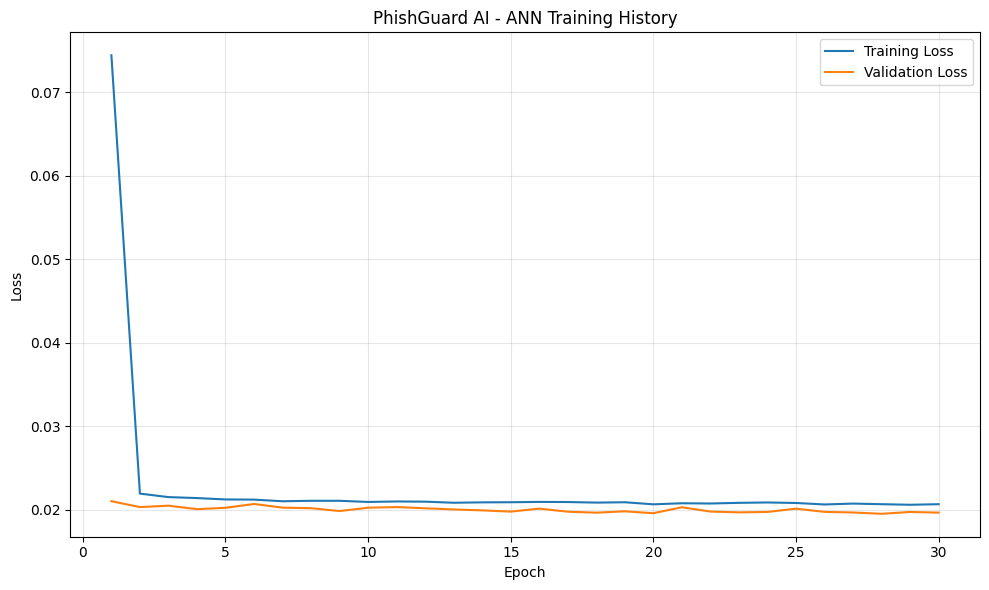

Training history saved to:
c:\Users\Manid\project1\results\training_history.png


In [103]:
# Cell 23: Plot training history

epochs_range = range(
    1,
    EPOCHS + 1
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["test_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "PhishGuard AI - ANN Training History"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    TRAINING_HISTORY_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Training history saved to:\n"
    f"{TRAINING_HISTORY_PATH}"
)

In [104]:
# Cell 24: Final evaluation

test_loss, test_accuracy, y_true, y_prob = (
    evaluate_model(
        model,
        test_loader,
        criterion,
        DEVICE
    )
)

y_pred = (
    y_prob >= 0.5
).astype(np.int64)

print(
    f"Test Loss : {test_loss:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)

Test Loss : 0.0197
Test Accuracy : 99.58%


In [105]:
# Cell 25: Calculate classification metrics

ann_accuracy = accuracy_score(
    y_true,
    y_pred
)

ann_precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

ann_recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

ann_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

ann_roc_auc = roc_auc_score(
    y_true,
    y_prob
)

ann_phishing_recall = recall_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

print("=" * 60)
print("ANN METRICS")
print("=" * 60)

print(
    f"Accuracy          : "
    f"{ann_accuracy * 100:.2f}%"
)

print(
    f"Precision         : "
    f"{ann_precision:.4f}"
)

print(
    f"Recall            : "
    f"{ann_recall:.4f}"
)

print(
    f"F1-score          : "
    f"{ann_f1:.4f}"
)

print(
    f"ROC-AUC           : "
    f"{ann_roc_auc:.4f}"
)

print(
    f"Phishing Recall   : "
    f"{ann_phishing_recall * 100:.2f}%"
)

ANN METRICS
Accuracy          : 99.58%
Precision         : 0.9932
Recall            : 0.9995
F1-score          : 0.9963
ROC-AUC           : 0.9982
Phishing Recall   : 99.09%


In [106]:
# Cell 26: Classification report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Phishing",
            "Legitimate"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [107]:
# Cell 27: ANN confusion matrix

cm_ann = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print(
    "ANN Confusion Matrix:"
)

print(cm_ann)

ANN Confusion Matrix:
[[20005   184]
 [   14 26956]]


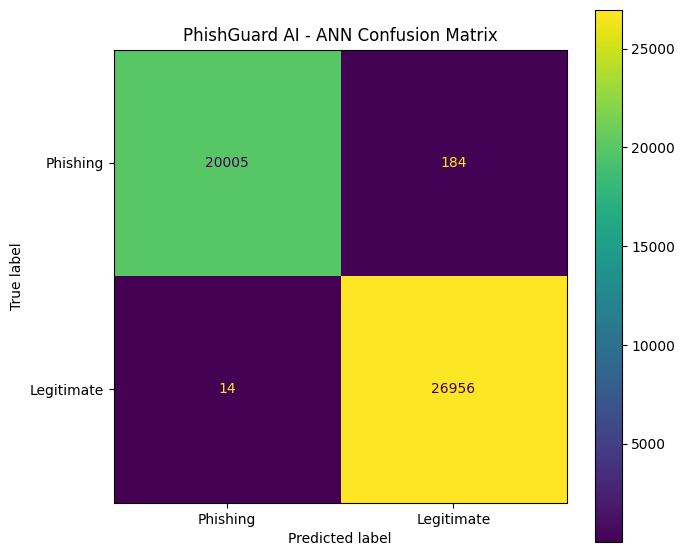

Saved to:
c:\Users\Manid\project1\results\confusion_matrix_ann.png


In [108]:
# Cell 28: Plot ANN confusion matrix

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm_ann,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

cm_display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "PhishGuard AI - ANN Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    ANN_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved to:\n"
    f"{ANN_CONFUSION_MATRIX_PATH}"
)

In [109]:
# Cell 29: Save ANN model

checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_size": INPUT_SIZE,
    "feature_names": X.columns.tolist(),
    "label_mapping": {
        0: "Phishing",
        1: "Legitimate"
    },
    "seed": SEED
}

torch.save(
    checkpoint,
    ANN_MODEL_PATH
)

print(
    "ANN model saved successfully. ✅"
)

print(
    f"\nModel path:\n{ANN_MODEL_PATH}"
)

ANN model saved successfully. ✅

Model path:
c:\Users\Manid\project1\models\ann_model.pth


In [110]:
# Cell 30: Save scaler

SCALER_PATH = (
    MODEL_DIR
    / "ann_scaler.joblib"
)

import joblib

joblib.dump(
    scaler,
    SCALER_PATH
)

print(
    "ANN scaler saved successfully. ✅"
)

print(
    f"\nScaler path:\n{SCALER_PATH}"
)

ANN scaler saved successfully. ✅

Scaler path:
c:\Users\Manid\project1\models\ann_scaler.joblib


In [111]:
# Cell 31: Save ANN metadata

ann_metadata = {
    "model": "PhishGuardANN",
    "framework": "PyTorch",
    "input_size": int(INPUT_SIZE),
    "hidden_layers": [
        128,
        64,
        32
    ],
    "activation": "ReLU",
    "dropout": [
        0.30,
        0.20
    ],
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "optimizer": "Adam",
    "loss_function": "BCEWithLogitsLoss",
    "test_size": 0.20,
    "random_state": SEED,
    "device": str(DEVICE),
    "label_mapping": {
        "0": "Phishing",
        "1": "Legitimate"
    },
    "features": X.columns.tolist(),
    "metrics": {
        "accuracy": float(ann_accuracy),
        "precision_legitimate": float(ann_precision),
        "recall_legitimate": float(ann_recall),
        "f1_legitimate": float(ann_f1),
        "roc_auc": float(ann_roc_auc),
        "phishing_recall": float(
            ann_phishing_recall
        )
    }
}

with open(
    ANN_METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        ann_metadata,
        file,
        indent=4
    )

print(
    "ANN metadata saved successfully. ✅"
)

ANN metadata saved successfully. ✅


In [112]:
# Cell 32: Reload saved ANN

checkpoint_loaded = torch.load(
    ANN_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

reloaded_model = PhishGuardANN(
    checkpoint_loaded["input_size"]
).to(DEVICE)

reloaded_model.load_state_dict(
    checkpoint_loaded["model_state_dict"]
)

reloaded_model.eval()

print(
    "Saved ANN reloaded successfully. ✅"
)

Saved ANN reloaded successfully. ✅


In [113]:
# Cell 33: Verify reloaded ANN

with torch.no_grad():

    sample_features = X_test_tensor[:10].to(
        DEVICE
    )

    original_output = model(
        sample_features
    )

    reloaded_output = reloaded_model(
        sample_features
    )

difference = torch.max(
    torch.abs(
        original_output
        - reloaded_output
    )
).item()

print(
    f"Maximum output difference: "
    f"{difference:.10f}"
)

if difference < 1e-5:
    print(
        "Reload verification passed. ✅"
    )
else:
    print(
        "Warning: outputs differ."
    )

Maximum output difference: 0.0000000000
Reload verification passed. ✅


In [114]:
# Cell 34: Final ANN summary

print("=" * 70)
print("PHISHGUARD AI - ANN TRAINING COMPLETE")
print("=" * 70)

print(
    f"Training samples : "
    f"{len(X_train):,}"
)

print(
    f"Testing samples  : "
    f"{len(X_test):,}"
)

print(
    f"Input features   : "
    f"{INPUT_SIZE}"
)

print(
    f"Accuracy         : "
    f"{ann_accuracy * 100:.2f}%"
)

print(
    f"F1-score         : "
    f"{ann_f1:.4f}"
)

print(
    f"ROC-AUC          : "
    f"{ann_roc_auc:.4f}"
)

print(
    f"Phishing Recall  : "
    f"{ann_phishing_recall * 100:.2f}%"
)

print("\nGenerated files:")

print(
    f"✓ {ANN_MODEL_PATH}"
)

print(
    f"✓ {SCALER_PATH}"
)

print(
    f"✓ {ANN_METADATA_PATH}"
)

print(
    f"✓ {TRAINING_HISTORY_PATH}"
)

print(
    f"✓ {ANN_CONFUSION_MATRIX_PATH}"
)

print(
    "\nANN pipeline completed successfully. ✅"
)

PHISHGUARD AI - ANN TRAINING COMPLETE
Training samples : 188,636
Testing samples  : 47,159
Input features   : 23
Accuracy         : 99.58%
F1-score         : 0.9963
ROC-AUC          : 0.9982
Phishing Recall  : 99.09%

Generated files:
✓ c:\Users\Manid\project1\models\ann_model.pth
✓ c:\Users\Manid\project1\models\ann_scaler.joblib
✓ c:\Users\Manid\project1\models\ann_model_metadata.json
✓ c:\Users\Manid\project1\results\training_history.png
✓ c:\Users\Manid\project1\results\confusion_matrix_ann.png

ANN pipeline completed successfully. ✅
